In [1]:
# Function to parse IOB2 files and get sentence lengths

def parse_iob2_file(filepath):
    sentences = []
    tokens = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                if tokens:
                    sentences.append(tokens)
                    tokens = []
                continue
            splits = line.split("\t")
            tokens.append(splits[1])
    return sentences

import numpy as np

# Paths to files
train_path = "data/en_ewt-ud-train.iob2"
fin5_path = "data/FIN5_train.txt"

# Parse files
sentences_ewt = parse_iob2_file(train_path)
sentences_fin5 = parse_iob2_file(fin5_path)

# Compute lengths
lengths_ewt = [len(s) for s in sentences_ewt]
lengths_fin5 = [len(s) for s in sentences_fin5]

print("en_ewt-ud-train.iob2:")
print(f"Mean: {np.mean(lengths_ewt):.2f}, Min: {np.min(lengths_ewt)}, Max: {np.max(lengths_ewt)}")

print("FIN5_train.txt:")
print(f"Mean: {np.mean(lengths_fin5):.2f}, Min: {np.min(lengths_fin5)}, Max: {np.max(lengths_fin5)}")

en_ewt-ud-train.iob2:
Mean: 16.31, Min: 1, Max: 159
FIN5_train.txt:
Mean: 35.15, Min: 1, Max: 413


C:\Users\Andrius\AppData\Local\Temp\ipykernel_9728\3900518266.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([lengths_ewt, lengths_fin5], labels=["en_ewt-ud-train", "FIN5_train"])


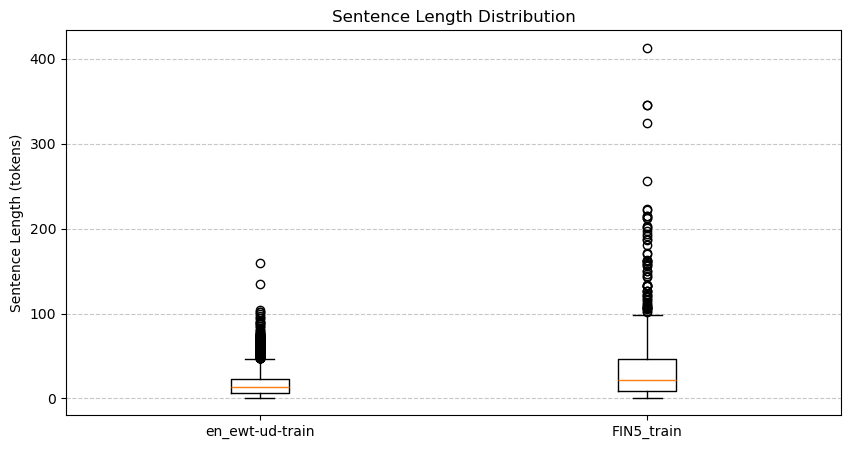

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.boxplot([lengths_ewt, lengths_fin5], labels=["en_ewt-ud-train", "FIN5_train"])
plt.ylabel("Sentence Length (tokens)")
plt.title("Sentence Length Distribution")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [9]:
# Evaluation of entity recognition per entity type for preds_fin5_128_model6.txt

def parse_pred_file(filepath):
    sentences = []
    labels = []
    tokens = []
    tags = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                if tokens:
                    sentences.append(tokens)
                    labels.append(tags)
                    tokens = []
                    tags = []
                continue
            splits = line.split("\t")
            tokens.append(splits[1])
            tags.append(splits[2])
    return sentences, labels

# Load gold and predicted labels
fin5_gold_path = "data/FIN5_dev.txt"
preds_path = "predictions/preds_fin5_256.txt"

gold_sentences, gold_labels = parse_pred_file(fin5_gold_path)
pred_sentences, pred_labels = parse_pred_file(preds_path)

from collections import Counter, defaultdict

entity_types = set(l for seq in gold_labels for l in seq if l != 'O')
entity_types = set([l[2:] for l in entity_types if l.startswith('B-') or l.startswith('I-')])

results = {}

for entity in entity_types:
    total = 0
    correct = 0
    # For special cases: count how many "Lender" and "Borrower" tokens were recognized as PERSON
    lender_total = 0
    lender_correct = 0
    borrower_total = 0
    borrower_correct = 0
    for gold_seq, pred_seq, tokens in zip(gold_labels, pred_labels, gold_sentences):
        for g, p, t in zip(gold_seq, pred_seq, tokens):
            if g.endswith(entity):
                total += 1
                if p.endswith(entity):
                    correct += 1
                # Check for Lender/Borrower tokens
                if t.lower() == "lender":
                    lender_total += 1
                    if p.endswith(entity):
                        lender_correct += 1
                if t.lower() == "borrower":
                    borrower_total += 1
                    if p.endswith(entity):
                        borrower_correct += 1
    results[entity] = {
        "total": total,
        "correct": correct,
        "accuracy": correct / total if total > 0 else 0,
        "lender_total": lender_total,
        "lender_correct": lender_correct,
        "lender_accuracy": lender_correct / lender_total if lender_total > 0 else 0,
        "borrower_total": borrower_total,
        "borrower_correct": borrower_correct,
        "borrower_accuracy": borrower_correct / borrower_total if borrower_total > 0 else 0
    }

import pprint
pprint.pprint(results)

{'LOC': {'accuracy': 0.8666666666666667,
         'borrower_accuracy': 0,
         'borrower_correct': 0,
         'borrower_total': 0,
         'correct': 52,
         'lender_accuracy': 0,
         'lender_correct': 0,
         'lender_total': 0,
         'total': 60},
 'ORG': {'accuracy': 0.7647058823529411,
         'borrower_accuracy': 0,
         'borrower_correct': 0,
         'borrower_total': 0,
         'correct': 13,
         'lender_accuracy': 0,
         'lender_correct': 0,
         'lender_total': 0,
         'total': 17},
 'PER': {'accuracy': 1.0,
         'borrower_accuracy': 1.0,
         'borrower_correct': 104,
         'borrower_total': 104,
         'correct': 208,
         'lender_accuracy': 1.0,
         'lender_correct': 92,
         'lender_total': 92,
         'total': 208}}


In [10]:
import pandas as pd

# Table for LOC, ORG, PER
main_entities = ['LOC', 'ORG', 'PER']
rows = []
for ent in main_entities:
    if ent in results:
        rows.append({
            'Entity': ent,
            'Accuracy': f"{results[ent]['accuracy']:.2%}",
            'Total': results[ent]['total'],
            'Correct': results[ent]['correct']
        })
main_df = pd.DataFrame(rows)
display(main_df)

# Table for Lender and Borrower as PERSON
lender_row = {
    'Type': 'Lender',
    'Total': results['PER']['lender_total'] if 'PER' in results else 0,
    'Correct as PER': results['PER']['lender_correct'] if 'PER' in results else 0,
    'Accuracy': f"{results['PER']['lender_accuracy']:.2%}" if 'PER' in results else '0%'
}
borrower_row = {
    'Type': 'Borrower',
    'Total': results['PER']['borrower_total'] if 'PER' in results else 0,
    'Correct as PER': results['PER']['borrower_correct'] if 'PER' in results else 0,
    'Accuracy': f"{results['PER']['borrower_accuracy']:.2%}" if 'PER' in results else '0%'
}
lender_borrower_df = pd.DataFrame([lender_row, borrower_row])
display(lender_borrower_df)

,Entity,Accuracy,Total,Correct
0,LOC,86.67%,60,52
1,ORG,76.47%,17,13
2,PER,100.00%,208,208


,Type,Total,Correct as PER,Accuracy
0,Lender,92,92,100.00%
1,Borrower,104,104,100.00%
